# Lung Cancer Regression Model

In [140]:
import os
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix

## Data Exploration

In [100]:
# Directory Path
path = os.getcwd()

In [101]:
# Import csv from directory path
Lung_Data = pd.read_csv(f"{path}/Lung_Cancer_Trends_Realistic.csv")

In [102]:
# Data dupicate
data = Lung_Data.copy()

In [103]:
# Data view
data.head()

,Patient_ID,Age,Gender,Smoking_Status,Years_Smoking,Cigarettes_Per_Day,Secondhand_Smoke_Exposure,Occupation_Exposure,Air_Pollution_Level,Family_History,...,Diet_Quality,Region,Income_Level,Education_Level,Access_to_Healthcare,Screening_Frequency,Chronic_Lung_Disease,Lung_Cancer_Stage,Diagnosis_Year,Survival_Status
0,P100000,76,Female,Never,6,37,Low,Diesel Fumes,Low,Yes,...,Poor,West,Middle,Tertiary,Good,Regularly,No,Stage II,2008,Alive
1,P100001,39,Male,Never,30,39,Low,Silica,Low,Yes,...,Average,North,Middle,Primary,Poor,Occasionally,Yes,NaN,2002,Alive
2,P100002,85,Male,Former,47,14,High,Asbestos,Low,Yes,...,Good,South,High,Tertiary,Average,Regularly,No,Stage II,2007,Deceased
3,P100003,45,Female,Current,45,32,Medium,Silica,High,No,...,Good,West,Low,Secondary,Average,Never,Yes,NaN,2011,Alive
4,P100004,48,Female,Never,46,26,Medium,Silica,Low,No,...,Good,North,Low,Tertiary,Average,Regularly,No,NaN,2016,Alive


In [104]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 3000 non-null   object 
 1   Age                        3000 non-null   int64  
 2   Gender                     3000 non-null   object 
 3   Smoking_Status             3000 non-null   object 
 4   Years_Smoking              3000 non-null   int64  
 5   Cigarettes_Per_Day         3000 non-null   int64  
 6   Secondhand_Smoke_Exposure  3000 non-null   object 
 7   Occupation_Exposure        2256 non-null   object 
 8   Air_Pollution_Level        3000 non-null   object 
 9   Family_History             3000 non-null   object 
 10  Genetic_Markers_Positive   3000 non-null   object 
 11  BMI                        3000 non-null   float64
 12  Physical_Activity_Level    3000 non-null   object 
 13  Alcohol_Consumption        2025 non-null   objec

In [105]:
# Duplicate detection
print(f'{data.duplicated().sum()} duplicates found')

0 duplicates found


In [106]:
data['Occupation_Exposure'].unique()

array(['Diesel Fumes', 'Silica', 'Asbestos', nan], dtype=object)

In [107]:
data['Occupation_Exposure'] = data['Occupation_Exposure'].fillna('None')
data['Occupation_Exposure'].unique()

array(['Diesel Fumes', 'Silica', 'Asbestos', 'None'], dtype=object)

In [108]:
data['Alcohol_Consumption'].unique()

array(['Moderate', 'High', nan], dtype=object)

In [109]:
data['Alcohol_Consumption'] = data['Alcohol_Consumption'].fillna('None')
data['Alcohol_Consumption'].unique()

array(['Moderate', 'High', 'None'], dtype=object)

In [110]:
data['Lung_Cancer_Stage'].unique()

array(['Stage II', nan, 'Stage III', 'Stage IV', 'Stage I'], dtype=object)

In [111]:
data['Lung_Cancer_Stage'] = data['Lung_Cancer_Stage'].fillna('None')
data['Lung_Cancer_Stage'].unique()

array(['Stage II', 'None', 'Stage III', 'Stage IV', 'Stage I'],
      dtype=object)

In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 3000 non-null   object 
 1   Age                        3000 non-null   int64  
 2   Gender                     3000 non-null   object 
 3   Smoking_Status             3000 non-null   object 
 4   Years_Smoking              3000 non-null   int64  
 5   Cigarettes_Per_Day         3000 non-null   int64  
 6   Secondhand_Smoke_Exposure  3000 non-null   object 
 7   Occupation_Exposure        3000 non-null   object 
 8   Air_Pollution_Level        3000 non-null   object 
 9   Family_History             3000 non-null   object 
 10  Genetic_Markers_Positive   3000 non-null   object 
 11  BMI                        3000 non-null   float64
 12  Physical_Activity_Level    3000 non-null   object 
 13  Alcohol_Consumption        3000 non-null   objec

In [113]:
data = data.drop(columns = 'Patient_ID', axis = 1)

In [114]:
data['Survival_Status'].value_counts()

Survival_Status
Alive       2534
Deceased     466
Name: count, dtype: int64

In [115]:
Lung_Data.describe()

,Age,Years_Smoking,Cigarettes_Per_Day,BMI,Diagnosis_Year
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,56.654333,24.226000,19.624000,24.972633,2012.129667
std,18.740880,14.292924,11.430289,4.962199,7.248105
min,25.000000,0.000000,0.000000,2.600000,2000.000000
25%,41.000000,12.000000,10.000000,21.600000,2006.000000
50%,57.000000,24.000000,19.000000,24.800000,2012.000000
75%,73.000000,36.000000,29.000000,28.300000,2018.000000
max,89.000000,49.000000,39.000000,45.700000,2024.000000


## Visualizations

In [ ]:
plt.figure(figsize=(5,5))
sns.scatterplot(data = Lung_Data, x = 'Income_Level', y ='BMI')
plt.show();

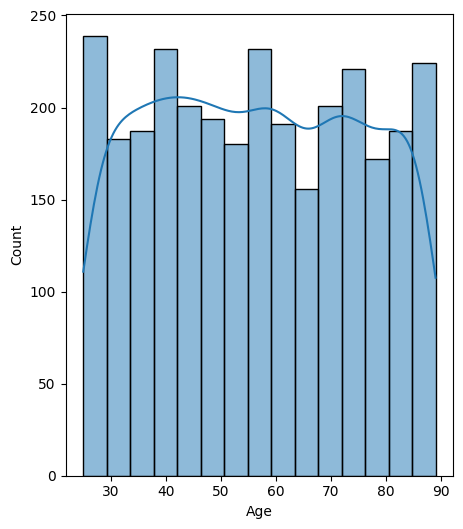

In [ ]:
plt.figure(figsize=(5,6))
sns.histplot(Lung_Data['Age'], kde=True)
plt.show();

## Feature Selection 

In [116]:
print('String columns' ,data.select_dtypes(include='object').columns.to_list())
str_list = data.select_dtypes(include='object').columns.to_list()

String columns ['Gender', 'Smoking_Status', 'Secondhand_Smoke_Exposure', 'Occupation_Exposure', 'Air_Pollution_Level', 'Family_History', 'Genetic_Markers_Positive', 'Physical_Activity_Level', 'Alcohol_Consumption', 'Diet_Quality', 'Region', 'Income_Level', 'Education_Level', 'Access_to_Healthcare', 'Screening_Frequency', 'Chronic_Lung_Disease', 'Lung_Cancer_Stage', 'Survival_Status']


In [ ]:
"""for column in data[str_list]:
    print(f'Values before encoding {data[column].value_counts()}')
    one_h = OneHotEncoder()
    data[column] = one_h.fit_transform(data[column])
    print(f"{column} Unique values after conversion= {data[column].unique()}")
    """

'\nfor column in data[str_list]:\n    print(f\'Values before encoding {data[column].value_counts()}\')\n    one_h = OneHotEncoder()\n    data[column] = one_h.fit_transform(data[column])\n    print(f"{column} Unique values after conversion= {data[column].unique()}")\n'

In [117]:

for column in data[str_list]:
    print(f'Values before encoding , {data[column].value_counts()}')
    Encode = LabelEncoder()
    data[column] = Encode.fit_transform(data[column])
    print(f"{column} Unique values after conversion= {data[column].unique()}, {data[column].value_counts()}")
    print('==' * 40)

   

Values before encoding , Gender
Male      1506
Female    1494
Name: count, dtype: int64
Gender Unique values after conversion= [0 1], Gender
1    1506
0    1494
Name: count, dtype: int64
Values before encoding , Smoking_Status
Current    1153
Former      935
Never       912
Name: count, dtype: int64
Smoking_Status Unique values after conversion= [2 1 0], Smoking_Status
0    1153
1     935
2     912
Name: count, dtype: int64
Values before encoding , Secondhand_Smoke_Exposure
Medium    1018
Low        991
High       991
Name: count, dtype: int64
Secondhand_Smoke_Exposure Unique values after conversion= [1 0 2], Secondhand_Smoke_Exposure
2    1018
1     991
0     991
Name: count, dtype: int64
Values before encoding , Occupation_Exposure
Silica          763
Diesel Fumes    753
None            744
Asbestos        740
Name: count, dtype: int64
Occupation_Exposure Unique values after conversion= [1 3 0 2], Occupation_Exposure
3    763
1    753
2    744
0    740
Name: count, dtype: int64
Value

#### Chronic Lung Disease 
No = 0 <br>
Yes = 1

#### Lung Cancer
None = 0 <br>
Stage I = 1 <br>
Stage III = 3 <br>
Stage IV = 4 <br>
Stage II = 2

#### Survival Status
Alive = 0 <br>
Deceased = 1

## Model Selection and Evaluation

## Chronic Lung Disease Model

In [118]:
X_cl = data.drop(['Chronic_Lung_Disease'], axis=1)
y_cl = data['Chronic_Lung_Disease']

In [119]:
X_cl_train, X_cl_test, y_cl_train, y_cl_test = train_test_split(X_cl, y_cl, test_size=0.25 , random_state=50)

In [121]:
print(y_cl_test.shape)

(750,)


In [122]:
scale = StandardScaler()
X_cl_train_scale = scale.fit_transform(X_cl_train)
X_cl_test_scale = scale.fit_transform(X_cl_test)


In [123]:
cl_lr= LogisticRegression(class_weight='balanced',max_iter = 100000, random_state=0)
cl_lr.fit(X_cl_train_scale,y_cl_train)

cl_lr_perd = cl_lr.predict(X_cl_test_scale)
cl_lr_prob = cl_lr.predict_proba(X_cl_test_scale)[:, 1]

In [124]:
print("Accuracy:", accuracy_score(y_cl_test, cl_lr_perd))
print("Precision:", precision_score(y_cl_test, cl_lr_perd , average='weighted'))
print("Recall:", recall_score(y_cl_test, cl_lr_perd, average='weighted'))
print("F1 Score:", f1_score(y_cl_test, cl_lr_perd, average='weighted'))

Accuracy: 0.524
Precision: 0.6690329387545033
Recall: 0.5239999999999999
F1 Score: 0.5674227998355351


In [125]:
print(classification_report(y_cl_test, cl_lr_perd,
                           target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.79      0.54      0.64       591
         Yes       0.22      0.47      0.30       159

    accuracy                           0.52       750
   macro avg       0.50      0.50      0.47       750
weighted avg       0.67      0.52      0.57       750



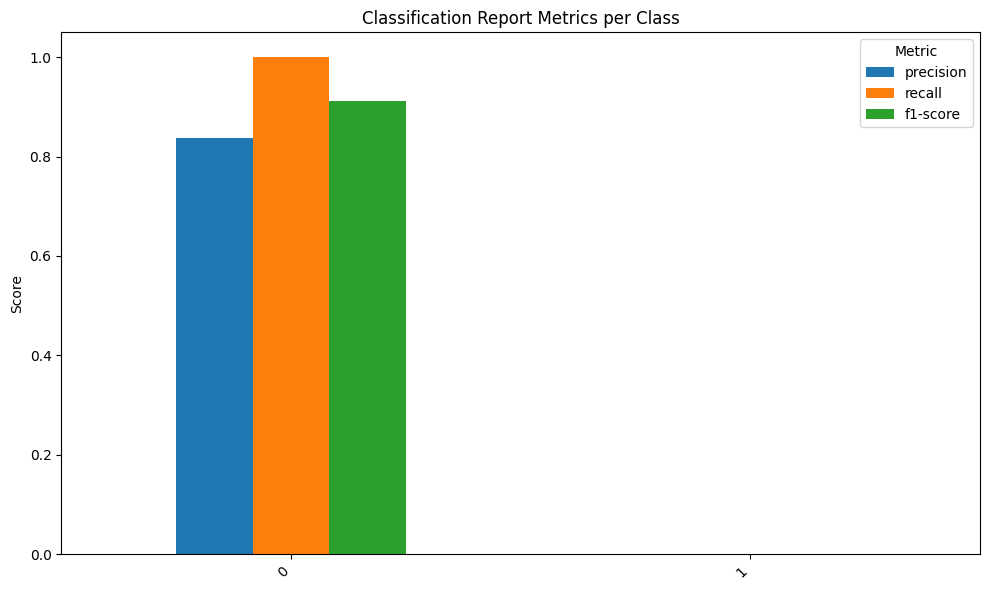

In [ ]:
metrics_to_plot = ['precision', 'recall', 'f1-score']
df_plot = rep.loc[rep.index.difference(['accuracy', 'macro avg', 'weighted avg']), metrics_to_plot]

df_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Classification Report Metrics per Class')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## Lung Cancer Model

In [ ]:
X_lc = data.drop(['Lung_Cancer_Stage'], axis=1)
y_lc = data['Lung_Cancer_Stage']


In [ ]:
X_lc_train, X_lc_test, y_lc_train, y_lc_test = train_test_split(X_lc, y_lc, test_size=0.25 , random_state=50)


In [ ]:
scale = StandardScaler()
X_lc_train_scale = scale.fit_transform(X_lc_train)
X_lc_test_scale = scale.fit_transform(X_lc_test)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
lc_dt= DecisionTreeClassifier()
lc_dt.fit(X_cl_train_scale,y_cl_train)


In [ ]:
lc_dt_perd = lc_dt.predict(X_cl_test_scale)
#lc_dt_prob = lc_dt.predict_proba(X_cl_test_scale)[:, 1]


In [ ]:
print(classification_report(y_lc_test, lc_dt_perd,
                           target_names=['No', 'Yes']))

## Survival Chance Model

In [ ]:
X_cl = data.drop(['Chronic_Lung_Disease'], axis=1)
y_cl = data['Chronic_Lung_Disease']


In [ ]:
X_cl_train, X_cl_test, y_cl_train, y_cl_test = train_test_split(X_cl, y_cl, test_size=0.25 , random_state=50)


In [ ]:
scale = StandardScaler()
X_cl_train_scale = scale.fit_transform(X_cl_train)
X_cl_test_scale = scale.fit_transform(X_cl_test)


In [ ]:
cl_lr= LogisticRegression(class_weight='balanced',max_iter = 100000, random_state=0)
cl_lr.fit(X_cl_train_scale,y_cl_train)


In [ ]:
cl_lr_perd = cl_lr.predict(X_cl_test_scale)
cl_lr_prob = cl_lr.predict_proba(X_cl_test_scale)[:, 1]


In [ ]:
print(classification_report(y_cl_test, cl_lr_perd,
                           target_names=['No', 'Yes']))